In [129]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




Try to fit a model of individual ED LOS based on their own triage acuity and the triage acuity of those around them. For this, we need a sense of the burden at every arrival point. 

In [ ]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)


#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
sim_vts['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_608/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Now see if we can fit a distribution to these 'times-to-arrival'. (If not, the crowding history will nonetheless be helpful for predicting individual level ED-LOS with RNNs, for which we'd need admission status and visit diagnoses).

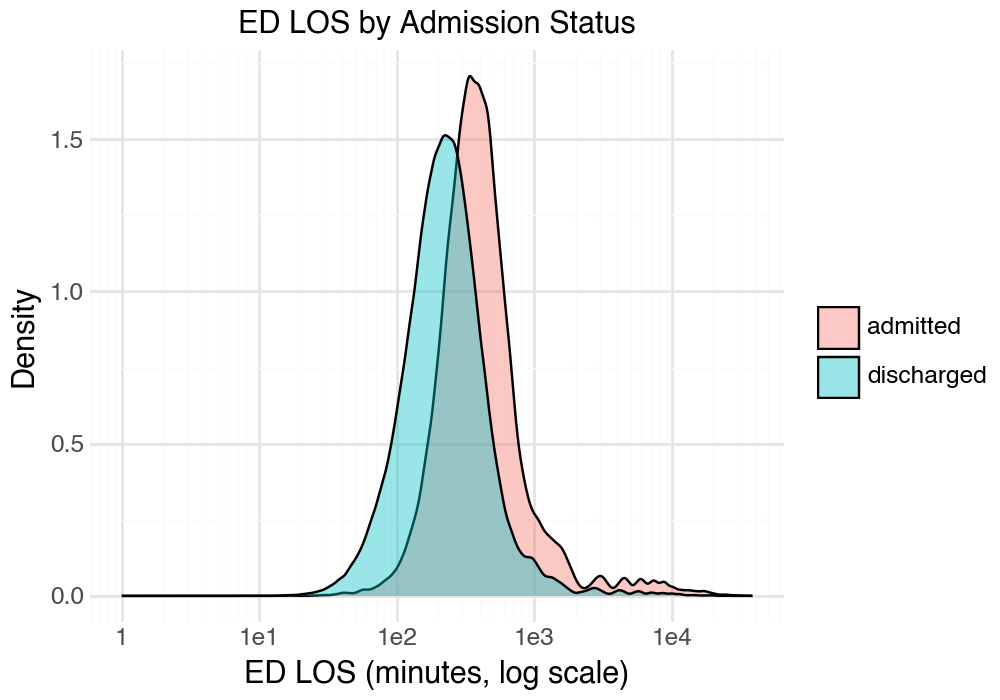

In [5]:
#Load this.
%matplotlib inline
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

from plotnine import (
    ggplot, aes, geom_density, scale_x_log10,
    labs, theme, theme_minimal, element_text
)

plot_df = visit_timeline.copy()
plot_df['admission_status'] = plot_df['is_admitted'].map({1: 'admitted', 0: 'discharged'})
plot_df['urgency_status'] = plot_df['urgent'].map({1: 'urgent', 0: 'non-urgent'})

def los_density_plot(df, fill_col, title):
    return (
        ggplot(df, aes(x='ed_los', fill=fill_col))
        + geom_density(alpha=0.4)
        + scale_x_log10()
        + labs(title=title, x='ED LOS (minutes, log scale)', y='Density', fill='')
        + theme_minimal()
        + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
    )

#Plot by admission status.
los_density_plot(plot_df, 'admission_status', 'ED LOS by Admission Status')


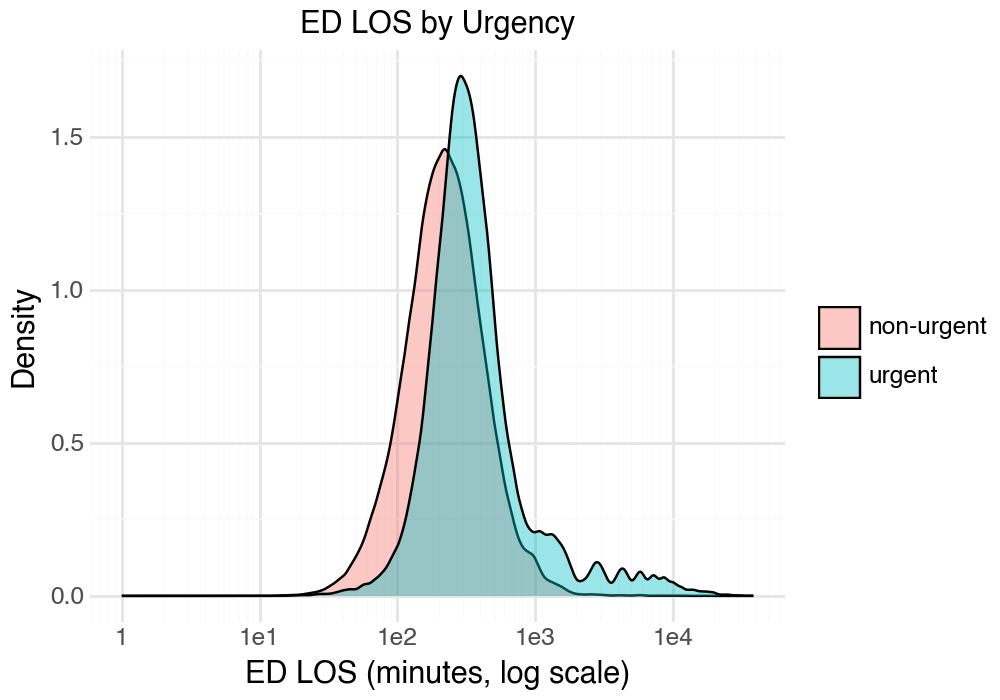

In [6]:
#Plot by urgency.
los_density_plot(plot_df, 'urgency_status', 'ED LOS by Urgency')



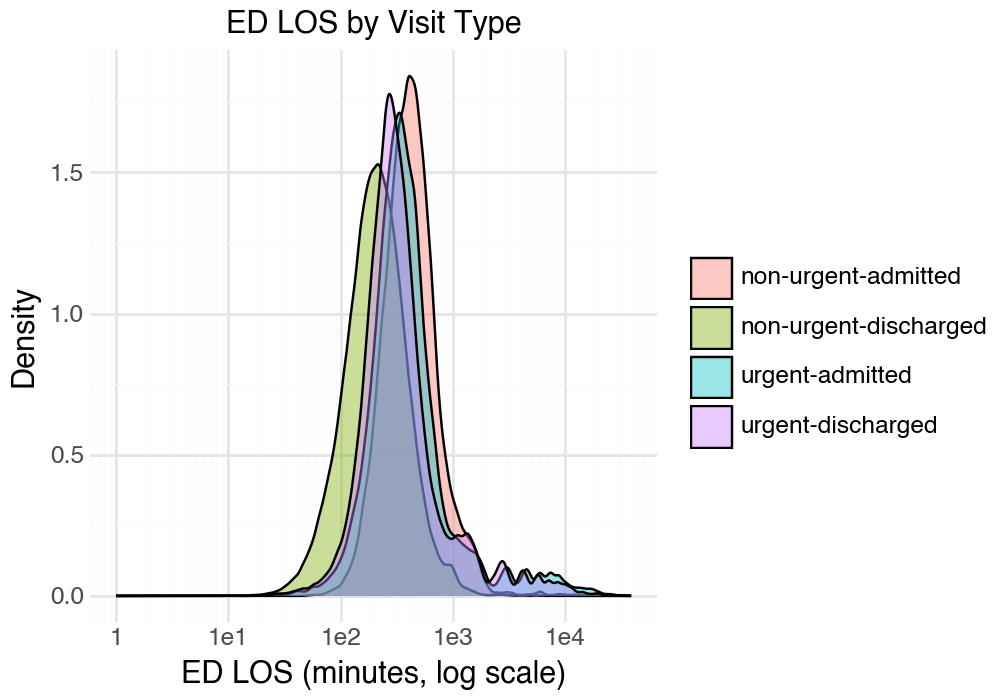

In [7]:
#Plot by visit type.
los_density_plot(plot_df, 'visit_type', 'ED LOS by Visit Type')

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


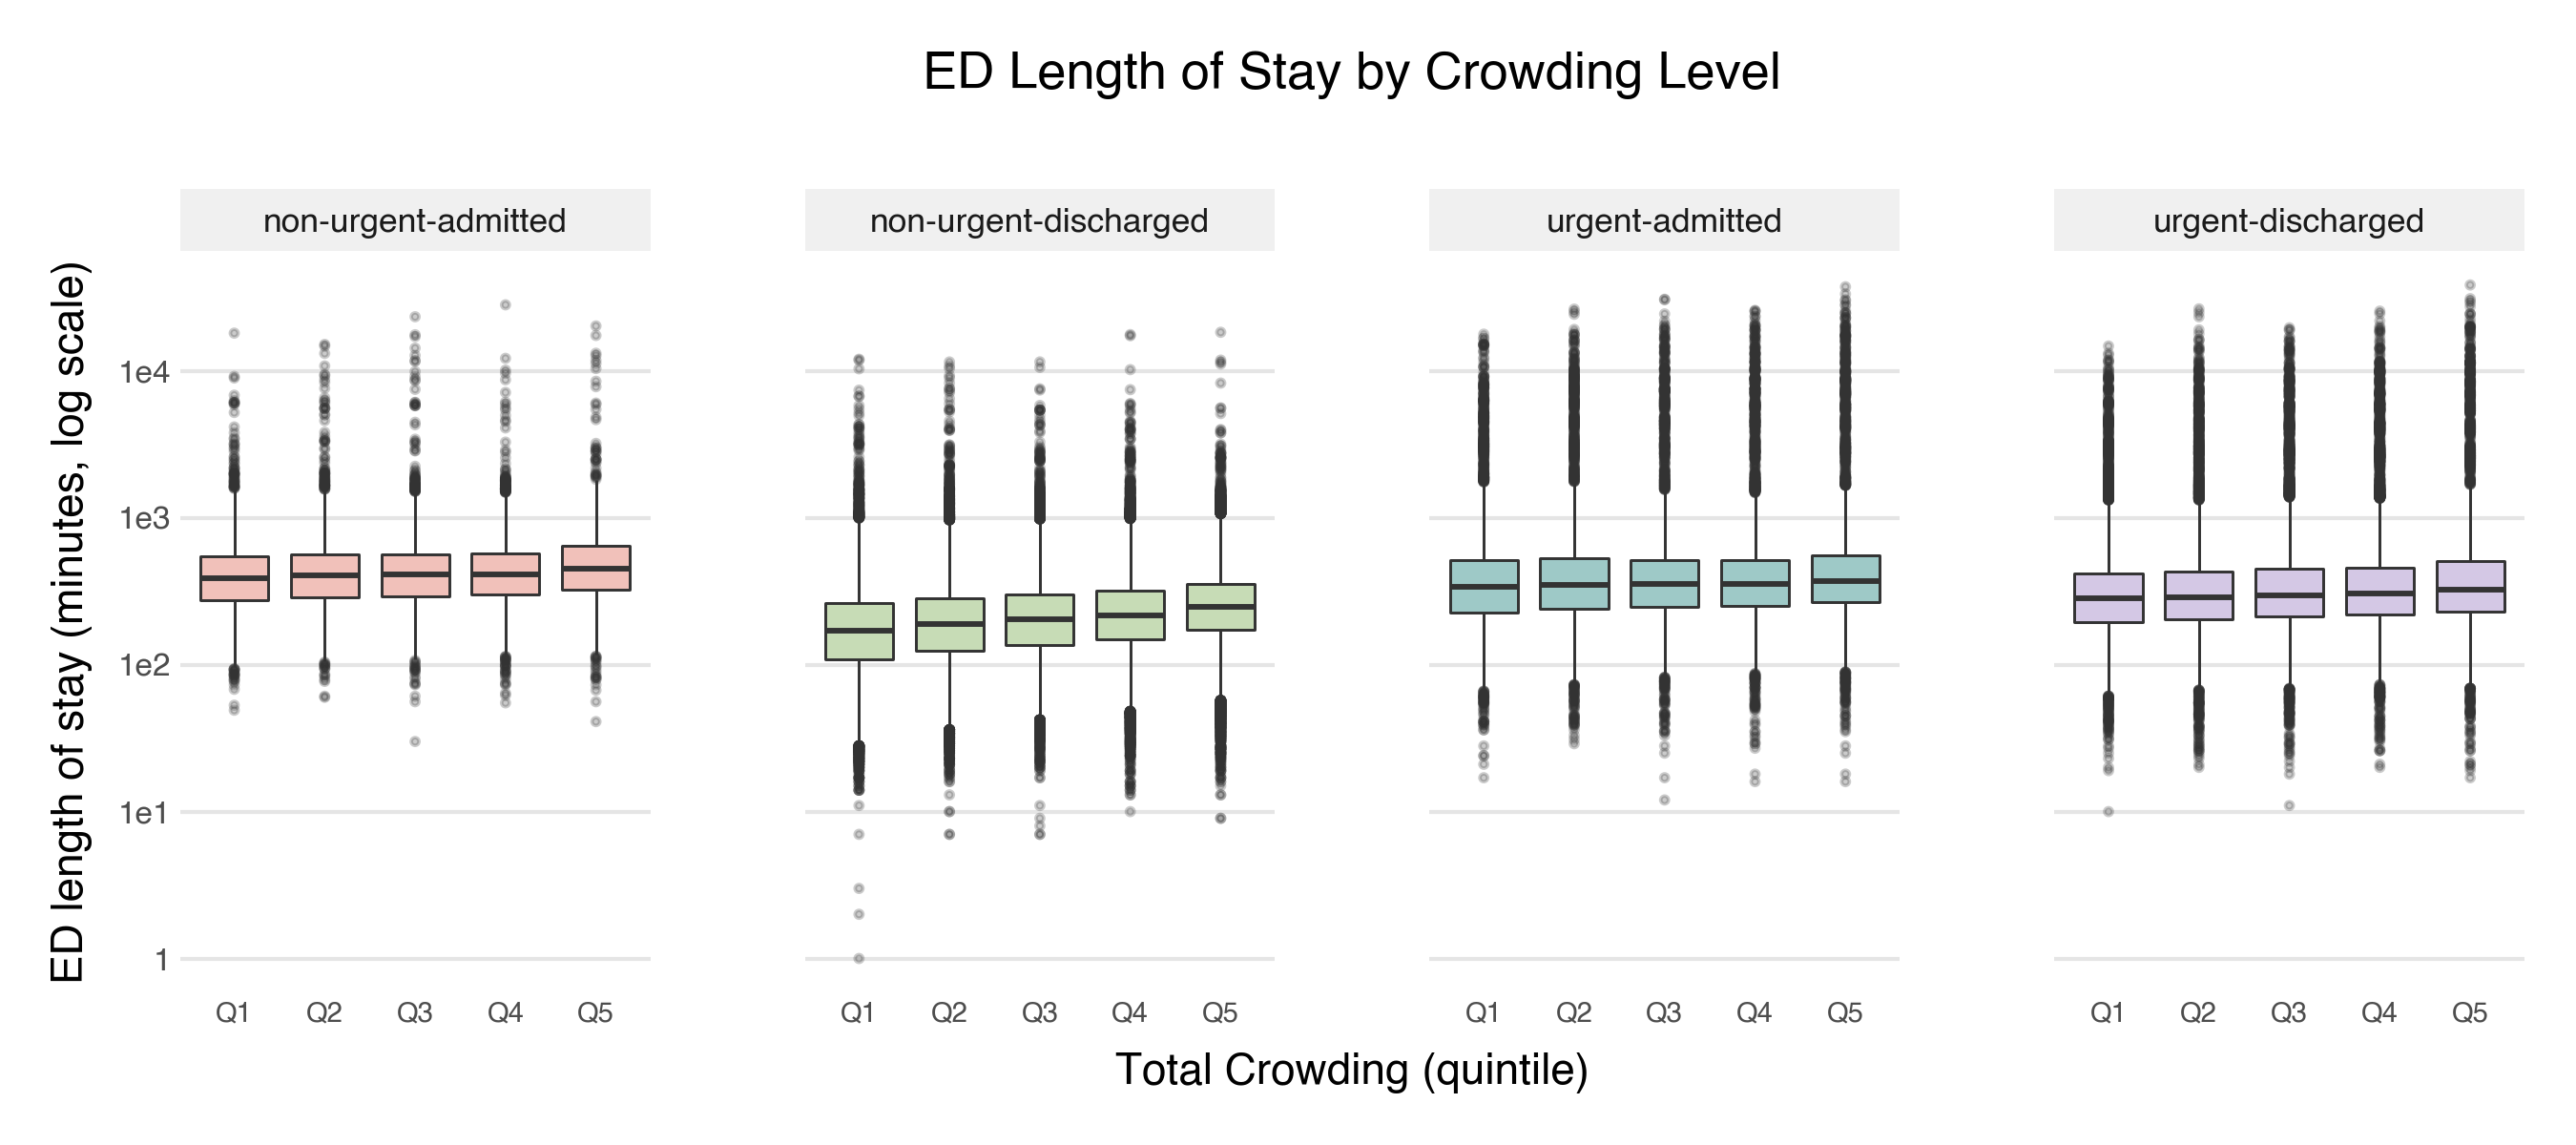

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


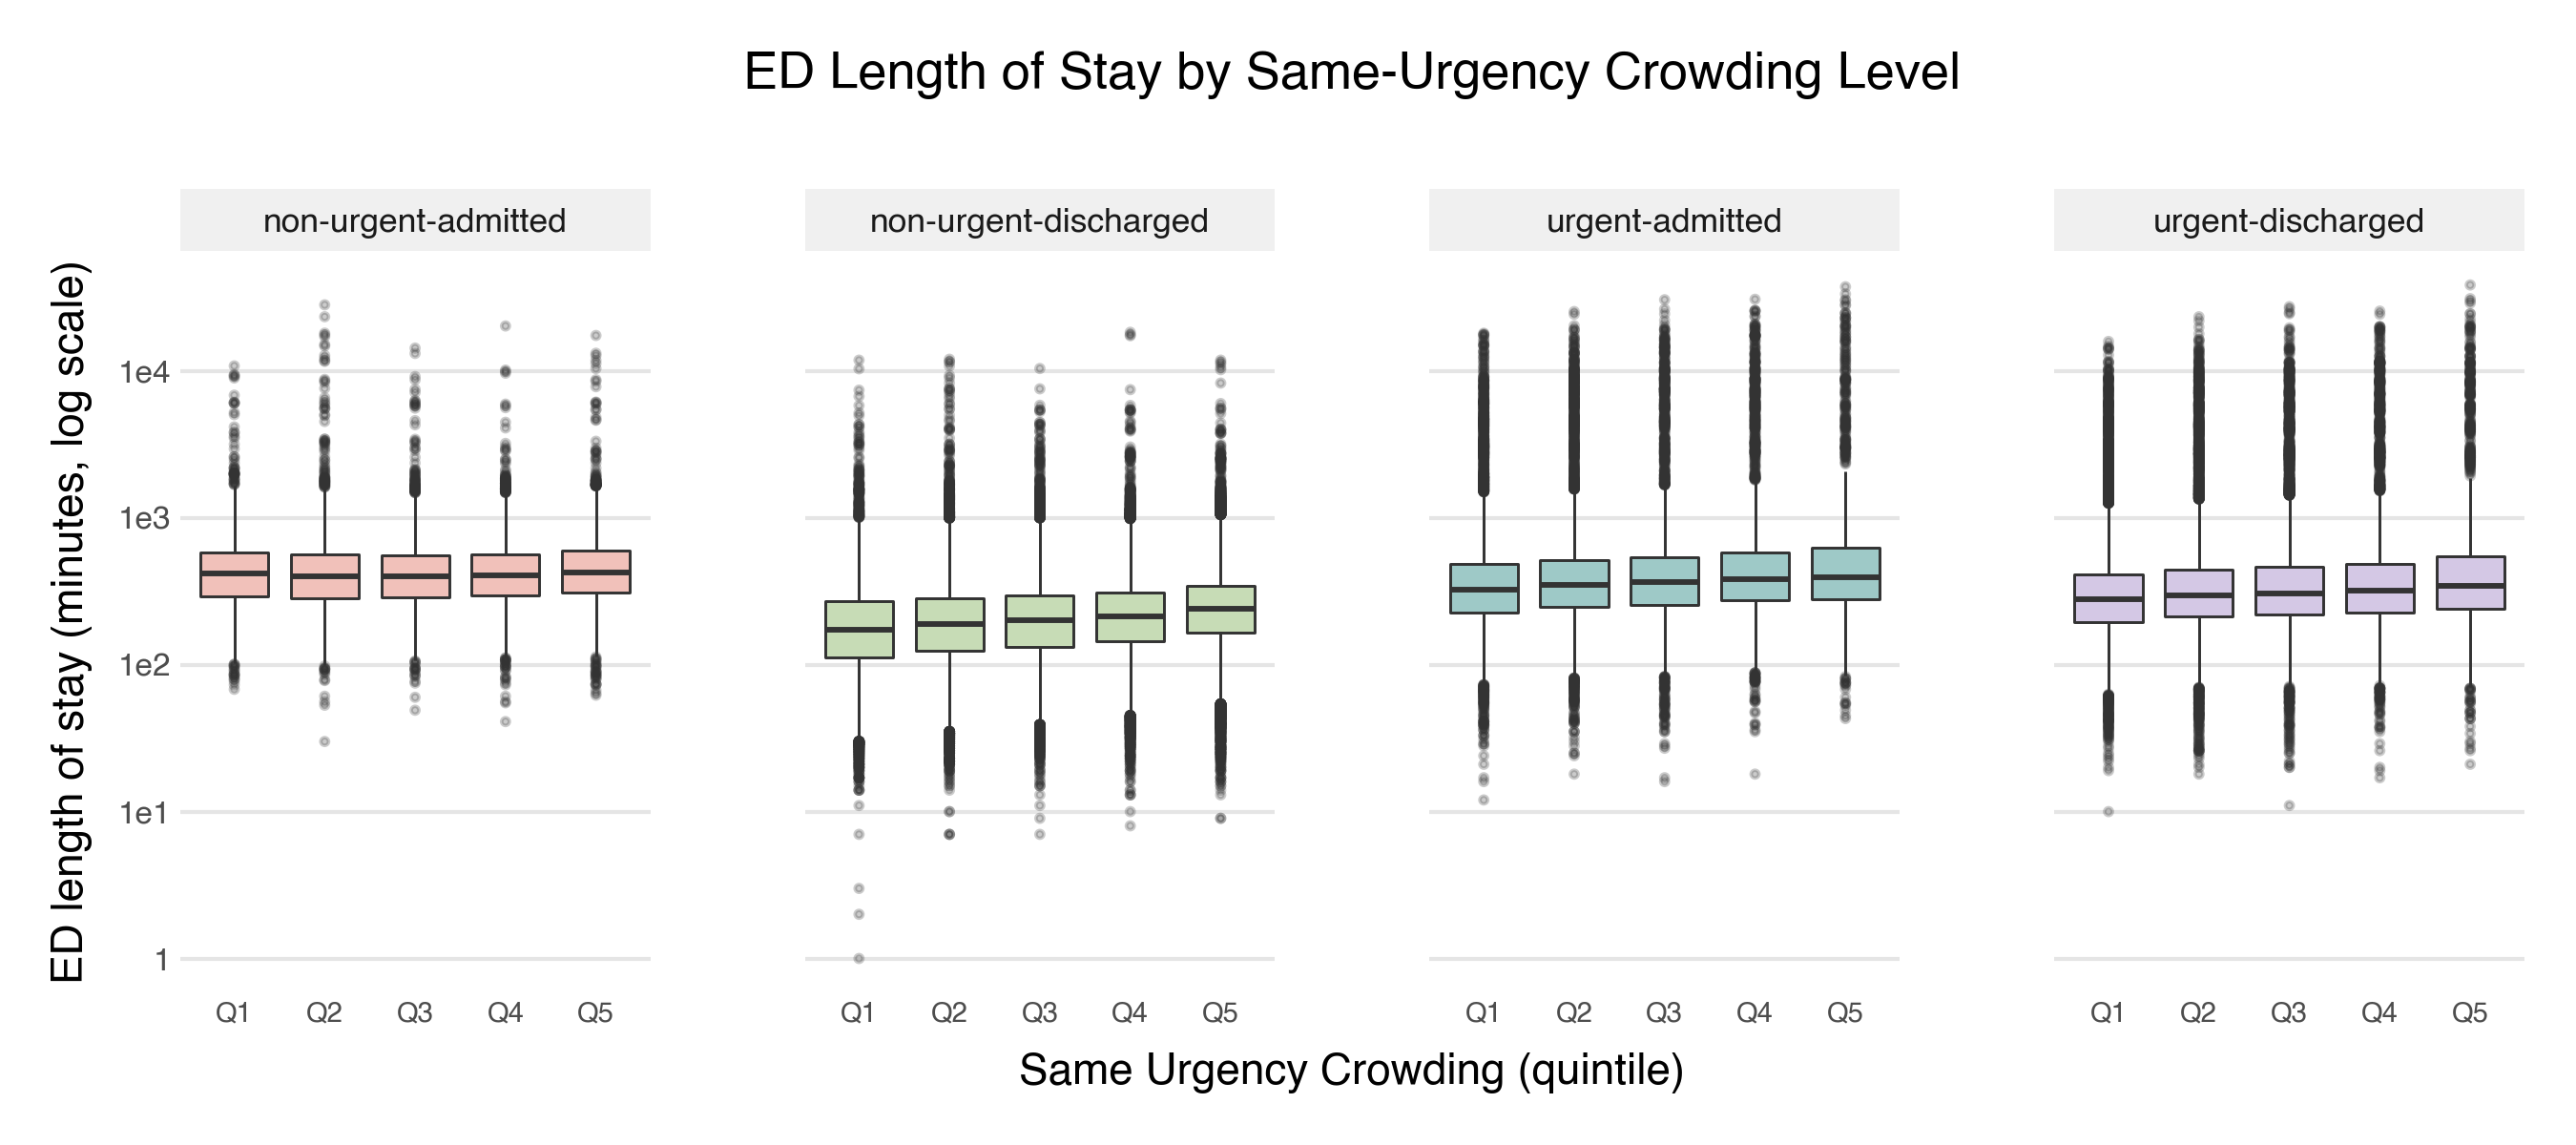

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


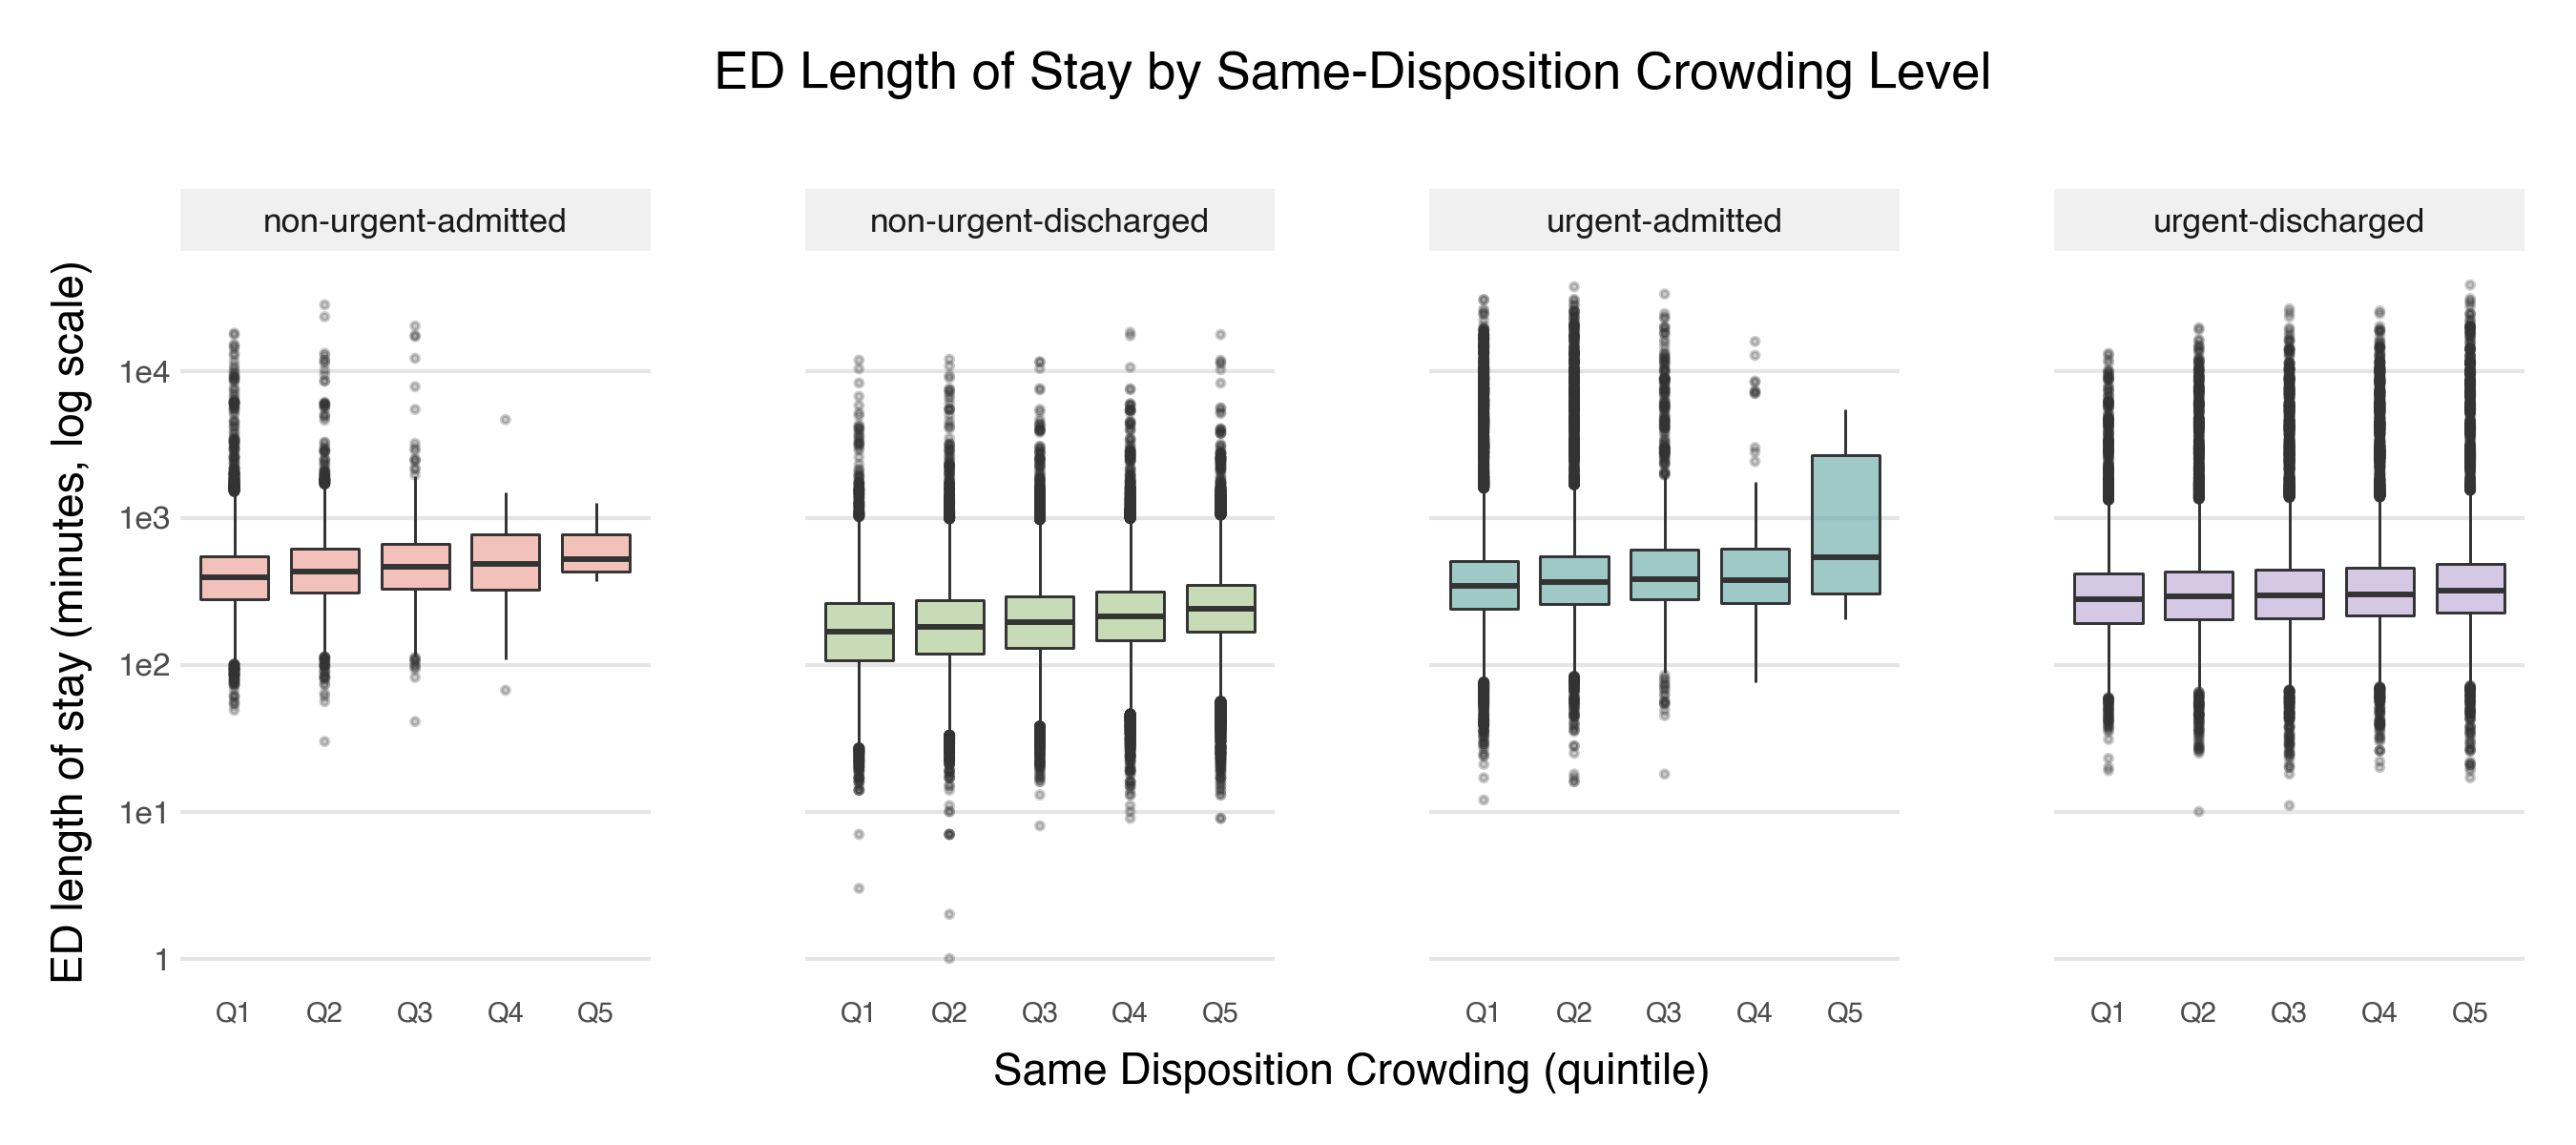

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


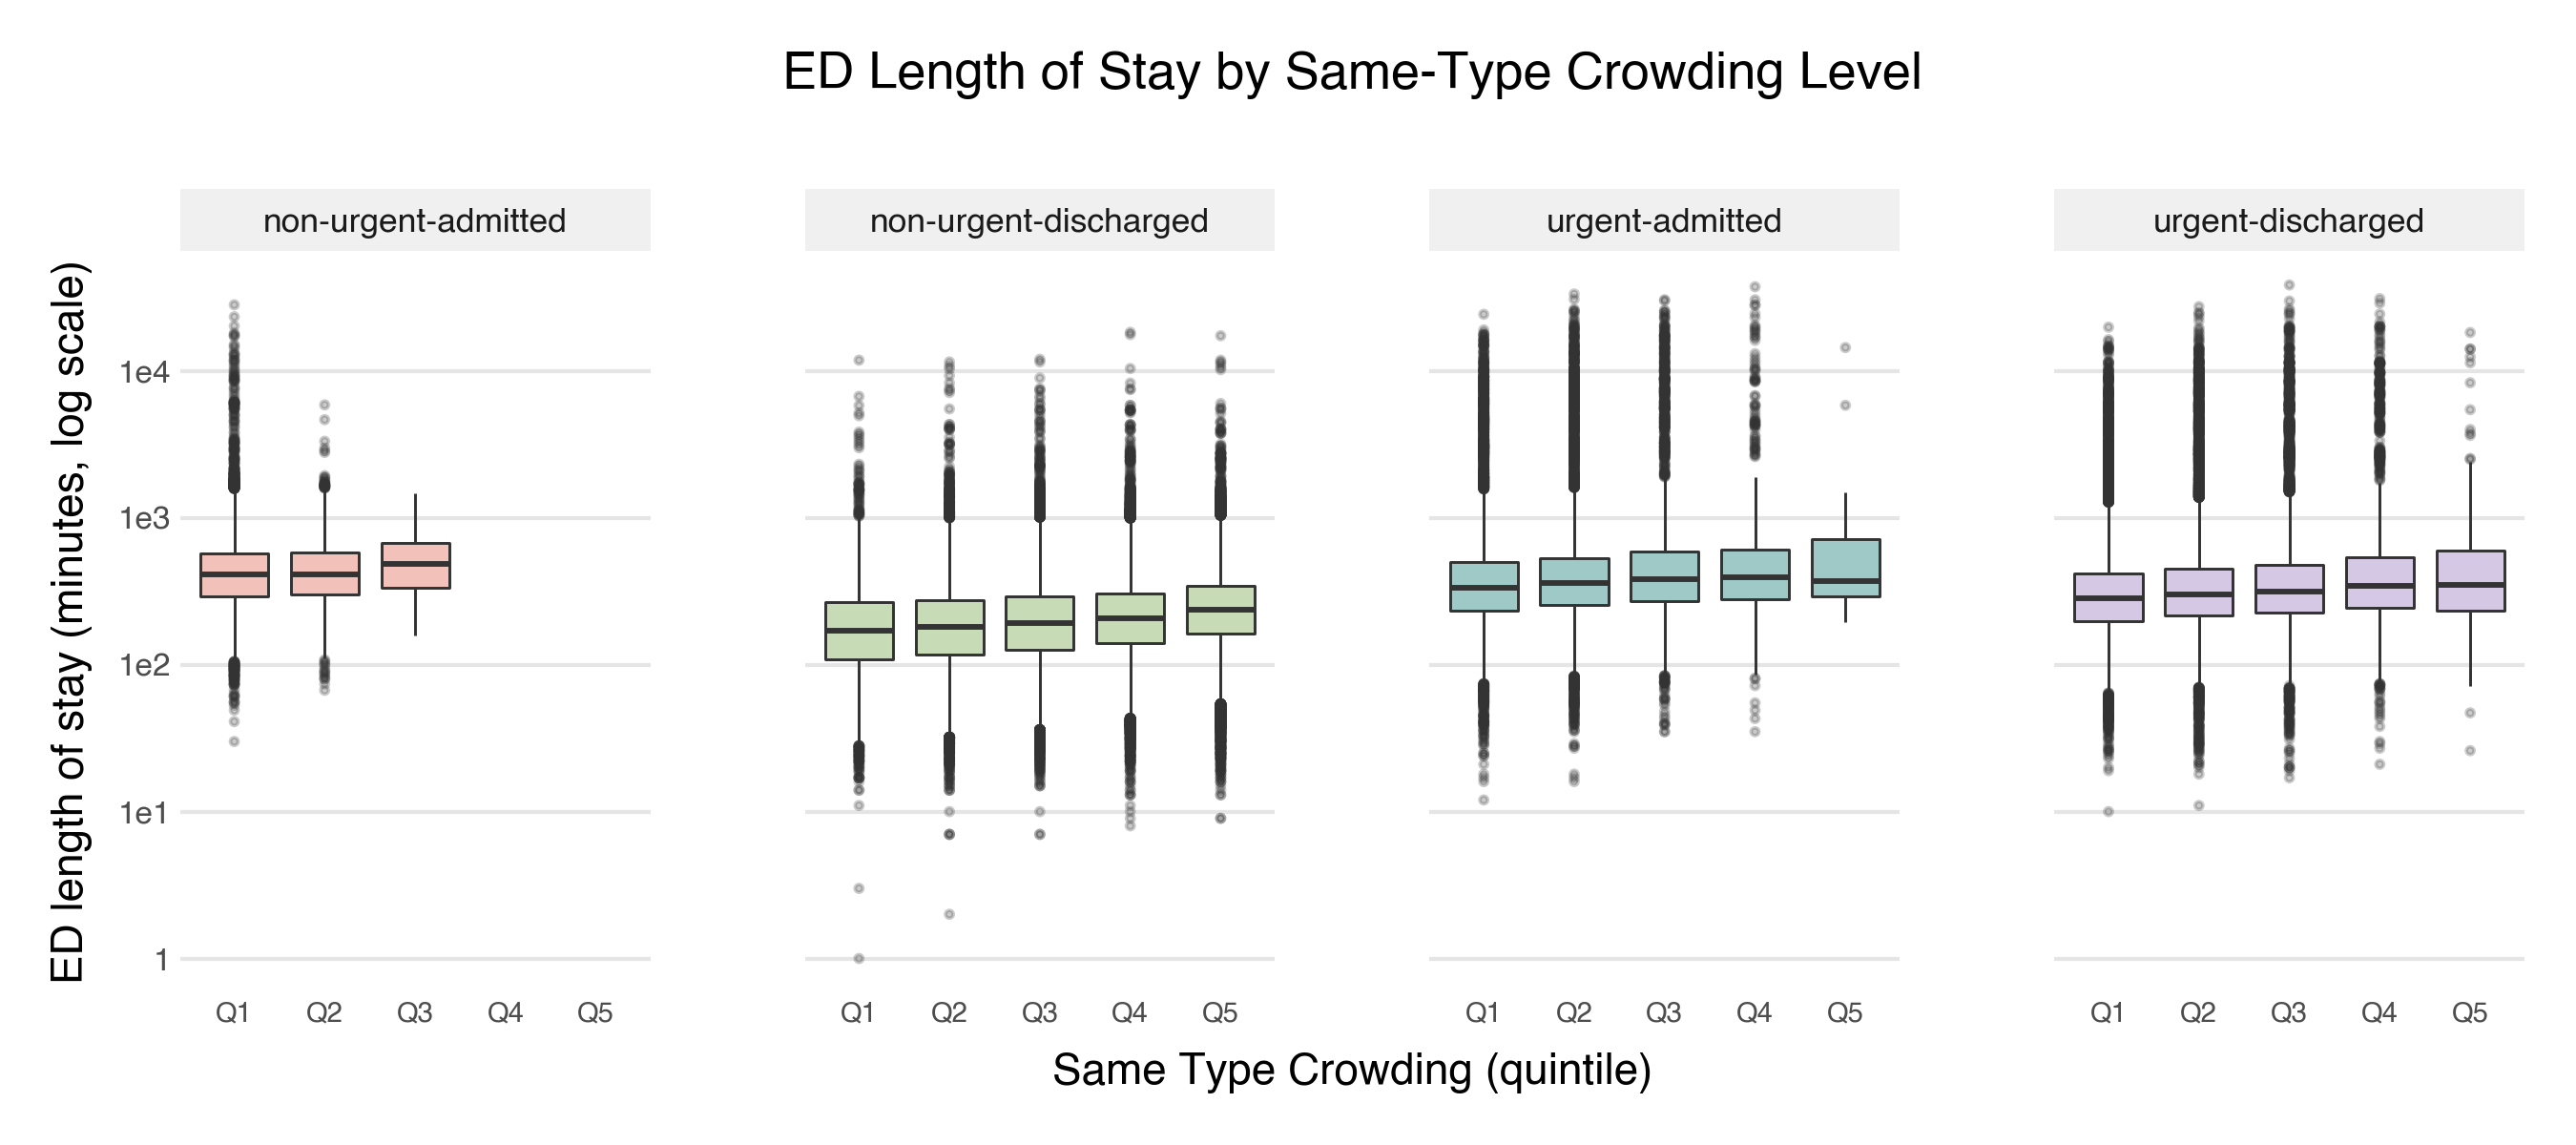

In [7]:
%matplotlib inline

import pandas as pd
import numpy as np
from plotnine import *

# # Load data
# visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)
# visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])
# visit_timeline['total-crowding'] = (
#     visit_timeline['non-urgent-admitted'] + visit_timeline['urgent-admitted']
#     + visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-discharged']
# )

# #Collate crowding types.
# visit_timeline['urgent-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['urgent-admitted']
# visit_timeline['non-urgent-crowding'] = visit_timeline['non-urgent-admitted'] + visit_timeline['non-urgent-discharged']
# visit_timeline['admit-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-admitted']
# visit_timeline['discharge-crowding'] = visit_timeline['non-urgent-discharged'] + visit_timeline['urgent-discharged']
# visit_timeline['same-urgency-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'urgent-discharged']), visit_timeline['urgent-crowding'], visit_timeline['non-urgent-crowding'])
# visit_timeline['same-disposition-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'non-urgent-admitted']), visit_timeline['admit-crowding'], visit_timeline['discharge-crowding'])


# #Get crowding of the same type.
# crowding_cols = ['non-urgent-admitted', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged']
# conditions = [visit_timeline['visit_type'] == c for c in crowding_cols]
# choices = [visit_timeline[c] for c in crowding_cols]
# visit_timeline['same-type-crowding'] = np.select(conditions, choices)

# #Save these.
# visit_timeline.to_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv')


#Load back data.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)

# Nicer palette (soft but distinct)
crowding_colors = {
    'non-urgent-admitted': '#E8998D',
    'non-urgent-discharged': '#A3C586',
    'urgent-admitted': '#5DA5A3',
    'urgent-discharged': '#B8A4D4',
}
def crowding_plot(df, crowding_type, title, bins=5):
    df_binned = df.copy()
    df_binned['crowding_binned'] = pd.qcut(
        df[crowding_type], q=bins,
        labels=[f'Q{i+1}' for i in range(bins)]
    )

    return (
        ggplot(df_binned, aes(x='crowding_binned', y='ed_los', fill='visit_type'))
        + geom_boxplot(alpha=0.6, outlier_size=0.6, outlier_alpha=0.25, size=0.4)
        + scale_y_log10()
        + scale_fill_manual(values=crowding_colors)
        + facet_grid('~ visit_type')
        + labs(
            title=title,
            y='ED length of stay (minutes, log scale)',
            x=f'{crowding_type.replace("-", " ").title()} (quintile)',
            fill=''
        )
        + theme_minimal(base_size=11)
        + theme(
            figure_size=(9, 4),          # was 10x4.5 — too wide relative to content
            dpi=150,
            plot_title=element_text(size=13, weight='bold', margin={'b': 10}),
            strip_text=element_text(size=8.5, weight='bold'),
            strip_background=element_rect(fill='#F0F0F0', color='none'),
            axis_text_x=element_text(size=7, rotation=0),  # Q1-Q5 short enough to stay horizontal
            axis_text_y=element_text(size=8),
            panel_spacing=0.06,           
            panel_grid_minor=element_blank(),
            panel_grid_major_x=element_blank(),
            legend_position='none',
            plot_margin=0.02,
            subplots_adjust={'right': 0.98},  # stop the last strip label clipping
        )
    )

#Illustrate responsiveness to overall crowding.
p = crowding_plot(visit_timeline, 'total-crowding', 'ED Length of Stay by Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-urgency-crowding', 'ED Length of Stay by Same-Urgency Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-disposition-crowding', 'ED Length of Stay by Same-Disposition Crowding Level')
p.show()

#Illustrate responsiveness to same-type crowding.
p = crowding_plot(visit_timeline, 'same-type-crowding', 'ED Length of Stay by Same-Type Crowding Level')
p.show()

In [8]:
# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df



In [126]:
#Fit a log-normal model to each visit type.

#Load data and attach seasonality.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)
visits = assign_age_group(visits, age_col='age_in_days') #Assign age group.


#Extract complaints.
complaints = ['complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting']

preconditions = ['pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse']

visit_timeline = visit_timeline.merge(visits[['csn', 'is_weekend', 'season', 'year_of_arrival', 'time_of_day',
                                              'age_group', 'insurance', 'ed_arrival_mode', 'language', 'race', 'sex',
                                              'physician_or_hospital_referral', 'miles_travelled', 'num_previous_admissions', 'num_previous_visits_without_admission'] +
                                              complaints + preconditions], on="csn", how='inner')

#We are interested in the effects of crowding on each model. Fit a model and control for chief complaint, miles travelled, age_
formula = "log_ed_los ~ is_weekend + C(season) + C(time_of_day) + C(year_of_arrival) " \
"+ C(ed_arrival_mode) + C(insurance) + C(language) + C(race) + C(sex) + C(age_group) + " \
"physician_or_hospital_referral + miles_travelled + num_previous_admissions + num_previous_visits_without_admission + " \
+ " + ".join(complaints) + " + " + " + ".join(preconditions) + " + C(visit_type)  + C(visit_type):(Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"

#Fit a single model in which everything interacts with visit-type.
model = smf.ols(formula, data=visit_timeline).fit()

ci = model.conf_int(alpha=0.05)
ci.columns = ['ci_lower', 'ci_upper']

summary_df = pd.DataFrame({
    'param': model.params.index,
    'exp(coef)': np.exp(model.params.values),
    'std_err': model.bse.values,
    'p_value': model.pvalues.values,
    'exp(ci_lower)': np.exp(ci['ci_lower'].values),
    'exp(ci_upper)': np.exp(ci['ci_upper'].values),
})

summary_df.to_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv')
summary_df

model.save("ed-los-model.pkl")


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_608/2922091635.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


In [110]:
import pandas as pd
import re
from itertools import combinations

def pairwise_visit_type_effects(model, visit_type_param_map, alpha=0.05, ref_state='C(visit_type)[T.non-urgent-admitted]'):
    """
    model: fitted statsmodels OLS result (log-scale outcome)
    visit_type_param_map: dict mapping display name -> patsy param name,
        e.g. {'Non-Urgent, Discharged': "C(visit_type)[T.non-urgent-discharged]", ...}
        Include the reference category with param name None.
    """
    from scipy.stats import norm
    z = norm.ppf(1 - alpha / 2)

    cov = model.cov_params()
    params = model.params

    states = list(visit_type_param_map.keys())
    records = []

    for state_from, state_to in combinations(states, 2):
        p_from = visit_type_param_map[state_from]
        p_to = visit_type_param_map[state_to]

        # coefficient relative to reference (0 if this IS the reference)
        beta_from = params[p_from] if p_from != ref_state else 0.0
        beta_to = params[p_to] if p_to != ref_state else 0.0

        # variance/covariance lookups, treating reference as fixed (variance 0, cov 0)
        var_from = cov.loc[p_from, p_from] if p_from != ref_state else 0.0
        var_to = cov.loc[p_to, p_to] if p_to != ref_state else 0.0
        cov_ft = cov.loc[p_from, p_to] if (p_from != ref_state and p_to != ref_state) else 0.0

        # switching FROM state_from TO state_to
        diff = beta_to - beta_from
        var_diff = var_to + var_from - 2 * cov_ft
        se_diff = np.sqrt(var_diff)

        pct_change = (np.exp(diff) - 1) 
        pct_lc = (np.exp(diff - z * se_diff) - 1) 
        pct_uc = (np.exp(diff + z * se_diff) - 1) 

        records.append({
            'from': state_from, 'to': state_to,
            'ED LOS Change [Est.]': pct_change,
            'ED LOS Change [LC]': pct_lc, 'ED LOS Change [UC]': pct_uc,
            'log_est':diff,
            'se':se_diff
        })
        # and the reverse direction (switching the other way)
        records.append({
            'from': state_to, 'to': state_from,
            'ED LOS Change [Est.]': -pct_change if False else (np.exp(-diff) - 1),
            'ED LOS Change [LC]': (np.exp(-diff - z * se_diff) - 1),
            'ED LOS Change [UC]': (np.exp(-diff + z * se_diff) - 1),
            'log_est':-diff,
            'se':se_diff,
        })

    return pd.DataFrame(records)

def parse_interaction_params(param_names):
    """
    Parse patsy interaction term names of the form:
    "C(visit_type)[level]:Q('crowding_type')"
    into a dataframe with separate visit_type and crowding_type columns.
    """
    pattern = re.compile(r"C\(visit_type\)\[([^\]]+)\]:Q\('([^']+)'\)")

    records = []
    for name in param_names:
        match = pattern.match(name)
        if match:
            visit_type, crowding_type = match.groups()
            records.append({
                'param': name,
                'visit_type': visit_type,
                'crowding_type': crowding_type
            })
        else:
            records.append({
                'param': name,
                'visit_type': None,
                'crowding_type': None
            })

    return pd.DataFrame(records)


#Format
def format_ci(row, mode='1sf'):
    est = row['ED LOS Change [Est.]'] * 100
    lc = row['ED LOS Change [LC]'] * 100
    uc = row['ED LOS Change [UC]'] * 100
    if mode=='1sf':
        return f"{est:.1f} ({lc:.1f}\u2013{uc:.1f})"
    else:
        return f"{est:.2f} ({lc:.2f}\u2013{uc:.2f})"

###-----LOAD COEFFICIENTS--------------------

#Load coefficients.
summary_df = pd.read_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv', index_col=0)

#Isolate coefficients of interest.
params_of_interest = summary_df[summary_df['param'].str.contains('urgent') | summary_df['param'].str.contains('admitted') | summary_df['param'].str.contains('discharged')].copy().reset_index(drop=True)

params_of_interest['ED LOS Change [Est.]'] = params_of_interest['exp(coef)']-1
params_of_interest['ED LOS Change [LC]'] = params_of_interest['exp(ci_lower)']-1
params_of_interest['ED LOS Change [UC]'] = params_of_interest['exp(ci_upper)']-1

#Extract names.
visit_type_names = {'C(visit_type)[T.non-urgent-discharged]': 'Non-Urgent, Discharged',
                    'C(visit_type)[T.urgent-admitted]':'Urgent, Admitted',
                    'C(visit_type)[T.urgent-discharged]': 'Urgent, Discharged',
                    'C(visit_type)[T.non-urgent-admitted]': 'Non-Urgent, Admitted'}

name_dict = {'non-urgent-discharged': 'Non-Urgent, Discharged',
                    'urgent-admitted':'Urgent, Admitted',
                    'urgent-discharged': 'Urgent, Discharged',
                    'non-urgent-admitted': 'Non-Urgent, Admitted'}



#Extract tables and relatable 
visit_type_effects = params_of_interest[~params_of_interest['param'].str.contains('Q')].copy().reset_index(drop=True)
visit_type_effects['Urgency-Disposition'] = visit_type_effects['param'].map(visit_type_names)

#Get estimates of the effects of switching from one state to another.
switching_effects = pairwise_visit_type_effects(model, visit_type_param_map={value: key for key, value in visit_type_names.items()})
switching_effects['ED LOS Change (%) [95% CI]'] = switching_effects.apply(format_ci, axis=1)

#Get estimates of the effect of 1 extra patients on crowding.
crowding_effects   = params_of_interest[params_of_interest['param'].str.contains('Q')].copy().reset_index(drop=True)
labels             = parse_interaction_params(crowding_effects['param'])
crowding_effects   = crowding_effects.merge(labels, on='param', how='inner')
crowding_effects['visit_type'] = crowding_effects['visit_type'].map(name_dict)
crowding_effects['crowding_type'] = crowding_effects['crowding_type'].map(name_dict)
crowding_effects['ED LOS Change (%) [95% CI]'] = crowding_effects.apply(lambda y: format_ci(y, mode='2sf'), axis=1)

#Save these.
switching_effects.to_csv("switching-effects.csv")
crowding_effects.to_csv('crowding-effects.csv')




In [111]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from plotnine import (
    ggplot, aes, geom_tile, geom_text, scale_fill_gradient2,
    labs, theme, theme_minimal, element_text, element_blank, element_rect
)

# ---------------------------------------------------------------------
# 1. Helpers to build a complete, consistently-ordered grid
# ---------------------------------------------------------------------

def build_full_grid(df, index_col, columns_col, value_col, annot_col, order,
                     diag_annot='\u2014'):  # em dash for missing/diagonal cells
    """
    Ensures every (index, columns) combination in `order` x `order` exists,
    filling any missing ones (e.g. a same-state 'switch') with NaN value
    and a placeholder annotation. Sets categorical order on both axes.
    """
    full_index = pd.DataFrame(
        list(product(order, order)), columns=[index_col, columns_col]
    )
    merged = full_index.merge(df[[index_col, columns_col, value_col, annot_col]],
                               on=[index_col, columns_col], how='left')
    merged[annot_col] = merged[annot_col].fillna(diag_annot)

    merged[index_col] = pd.Categorical(merged[index_col], categories=order[::-1], ordered=True)
    merged[columns_col] = pd.Categorical(merged[columns_col], categories=order, ordered=True)
    return merged


def compute_text_colors(values, cmap_name='RdBu_r', threshold=0.6):
    """
    Returns 'white' or 'black' per value so annotation text stays legible
    against both the darkest and lightest tiles. NaN -> 'black' (grey tile).
    """
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, 'black', dtype=object)
    finite = np.isfinite(values)
    if finite.any():
        vmax = np.nanmax(np.abs(values))
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        cmap = cm.get_cmap(cmap_name)
        rgba = cmap(norm(values[finite]))
        luminance = 0.299 * rgba[:, 0] + 0.587 * rgba[:, 1] + 0.114 * rgba[:, 2]
        out[finite] = np.where(luminance < threshold, 'white', 'black')
    return out


# ---------------------------------------------------------------------
# 2. Publication-ready heatmap
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
from itertools import product
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from plotnine import (
    ggplot, aes, geom_tile, geom_text, scale_fill_gradient2,
    labs, theme, theme_minimal, element_text, element_blank, element_rect
)

# ---------------------------------------------------------------------
# 1. Helpers to build a complete, consistently-ordered grid
# ---------------------------------------------------------------------

def build_full_grid(df, index_col, columns_col, value_col, annot_col, order,
                     diag_annot='\u2014'):  # em dash for missing/diagonal cells
    """
    Ensures every (index, columns) combination in `order` x `order` exists,
    filling any missing ones (e.g. a same-state 'switch') with NaN value
    and a placeholder annotation. Sets categorical order on both axes.
    """
    full_index = pd.DataFrame(
        list(product(order, order)), columns=[index_col, columns_col]
    )
    merged = full_index.merge(df[[index_col, columns_col, value_col, annot_col]],
                               on=[index_col, columns_col], how='left')
    merged[annot_col] = merged[annot_col].fillna(diag_annot)

    merged[index_col] = pd.Categorical(merged[index_col], categories=order[::-1], ordered=True)
    merged[columns_col] = pd.Categorical(merged[columns_col], categories=order, ordered=True)
    return merged


def compute_text_colors(values, cmap_name='RdBu_r', threshold=0.6):
    """
    Returns 'white' or 'black' per value so annotation text stays legible
    against both the darkest and lightest tiles. NaN -> 'black' (grey tile).
    """
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, 'black', dtype=object)
    finite = np.isfinite(values)
    if finite.any():
        vmax = np.nanmax(np.abs(values))
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        cmap = cm.get_cmap(cmap_name)
        rgba = cmap(norm(values[finite]))
        luminance = 0.299 * rgba[:, 0] + 0.587 * rgba[:, 1] + 0.114 * rgba[:, 2]
        out[finite] = np.where(luminance < threshold, 'white', 'black')
    return out


# ---------------------------------------------------------------------
# 2. Publication-ready heatmap
# ---------------------------------------------------------------------

def plot_annotated_heatmap(df, index_col, columns_col, value_col, annot_col, order,
                            title=None, xlab='To', ylab='From',
                            legend_title='ED LOS Change (%)',
                            figsize=(8, 6.5), base_size=13, annot_size=7.5,
                            save_path=None, dpi=300):
    plot_df = build_full_grid(df, index_col, columns_col, value_col, annot_col, order)
    plot_df['_value_pct'] = plot_df[value_col] * 100
    plot_df['_text_color'] = compute_text_colors(plot_df['_value_pct'])

    vmax = np.nanmax(np.abs(plot_df['_value_pct']))

    p = (
        ggplot(plot_df, aes(x=columns_col, y=index_col))
        + geom_tile(aes(fill='_value_pct'), color='white', size=0.8)
        + geom_text(aes(label=annot_col, color='_text_color'), size=annot_size,
                    lineheight=0.9, show_legend=False)
        + scale_fill_gradient2(
            low='#2166ac', mid='#f7f7f7', high='#b2182b', midpoint=0,
            limits=(-vmax, vmax), na_value='#e0e0e0', name=legend_title
        )
        + scale_color_manual(values={'black': 'black', 'white': 'white'}, guide=None)
        + labs(title=title or '', x=xlab, y=ylab)
        + theme_minimal(base_size=base_size)
        + theme(
            figure_size=figsize,
            axis_text_x=element_text(rotation=45, hjust=1),
            axis_ticks=element_blank(),
            panel_grid=element_blank(),
            plot_title=element_text(weight='bold', size=base_size + 1, ha='center'),
            legend_title=element_text(size=base_size - 1),
            plot_background=element_rect(fill='white', color=None),
        )
    )

    if save_path:
        p.save(save_path, dpi=dpi, width=figsize[0], height=figsize[1])
    return p


# need this import for scale_color_manual used above
from plotnine import scale_color_manual

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_608/1349120234.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation//outputs/fig_switching_effects.pdf


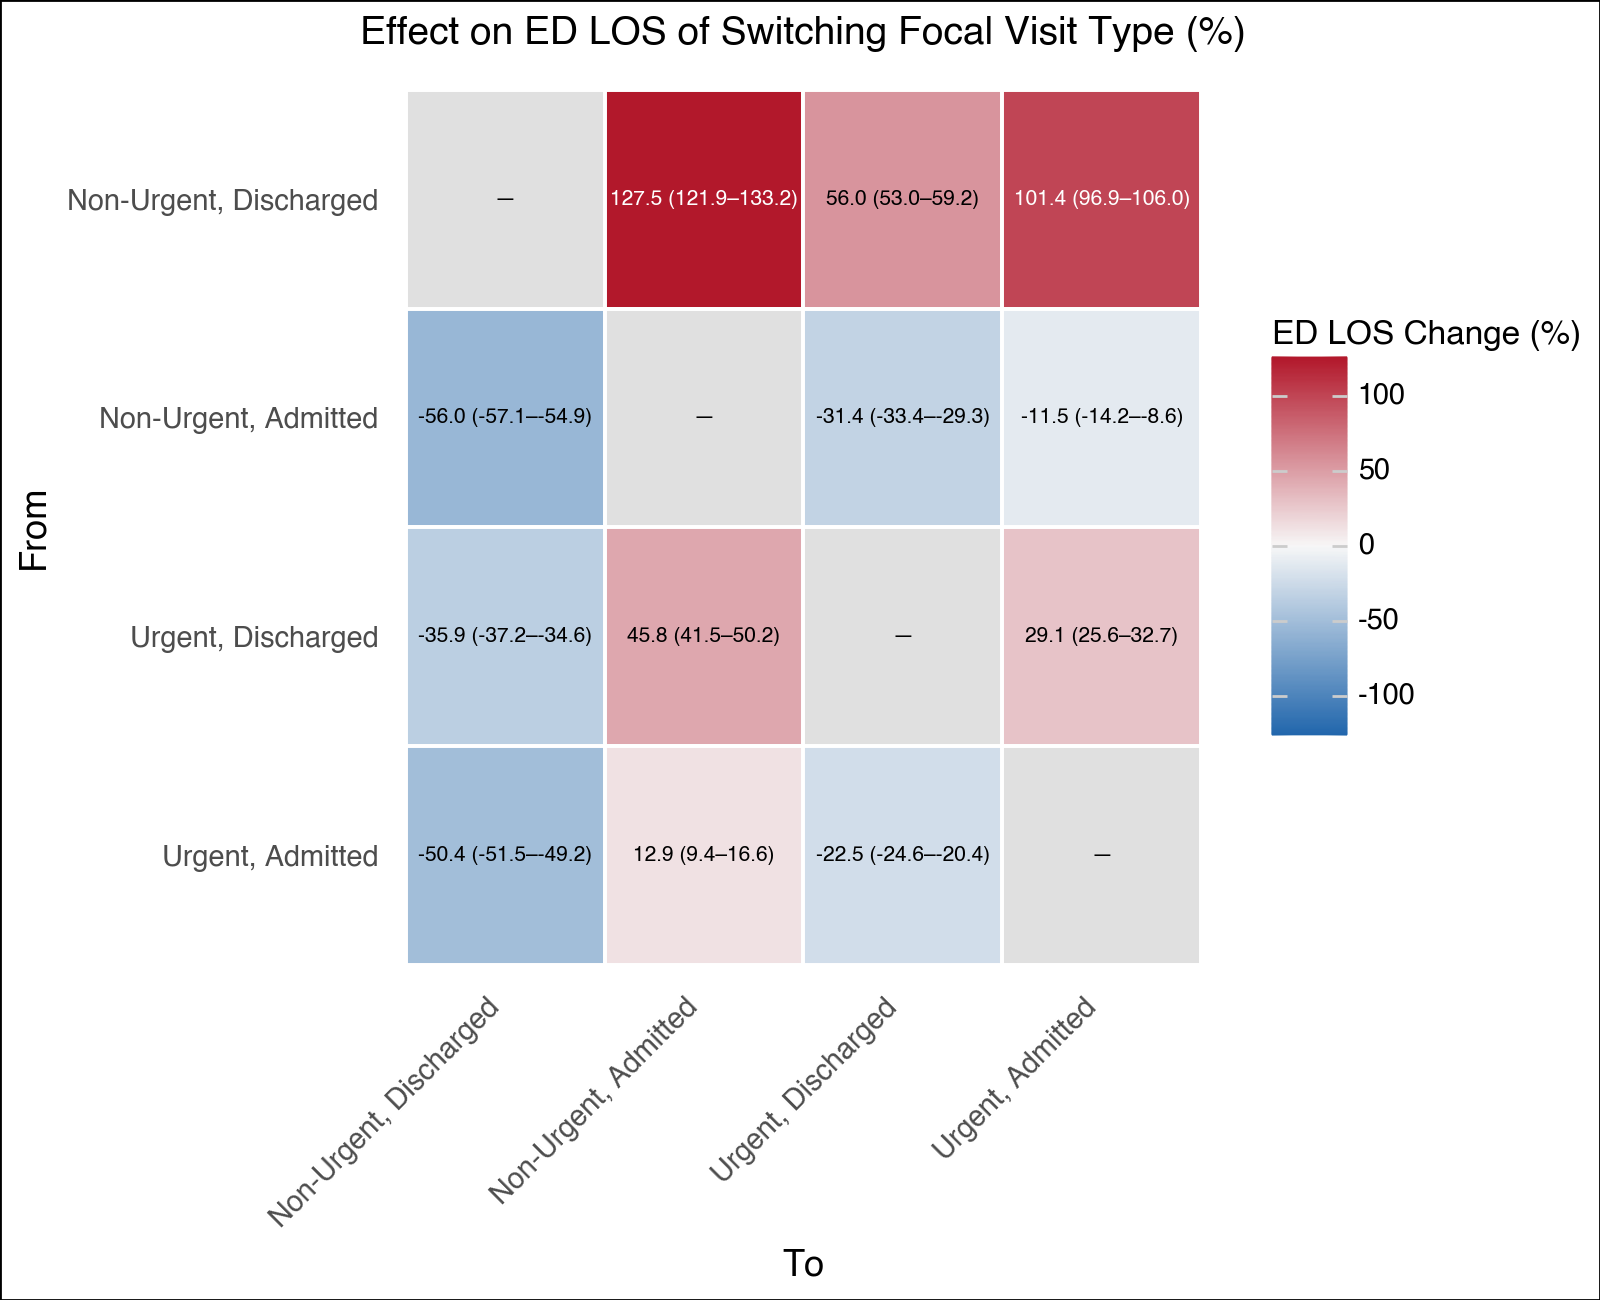

In [135]:
ORDER = ['Non-Urgent, Discharged', 'Non-Urgent, Admitted', 'Urgent, Discharged', 'Urgent, Admitted']

p_switch = plot_annotated_heatmap(
    switching_effects, index_col='from', columns_col='to',
    value_col='ED LOS Change [Est.]', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, title='Effect on ED LOS of Switching Focal Visit Type (%)',
    save_path=save_filepath + '/outputs/fig_switching_effects.pdf'
)
p_switch



/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_608/1349120234.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation//outputs/fig_crowding_effects.pdf


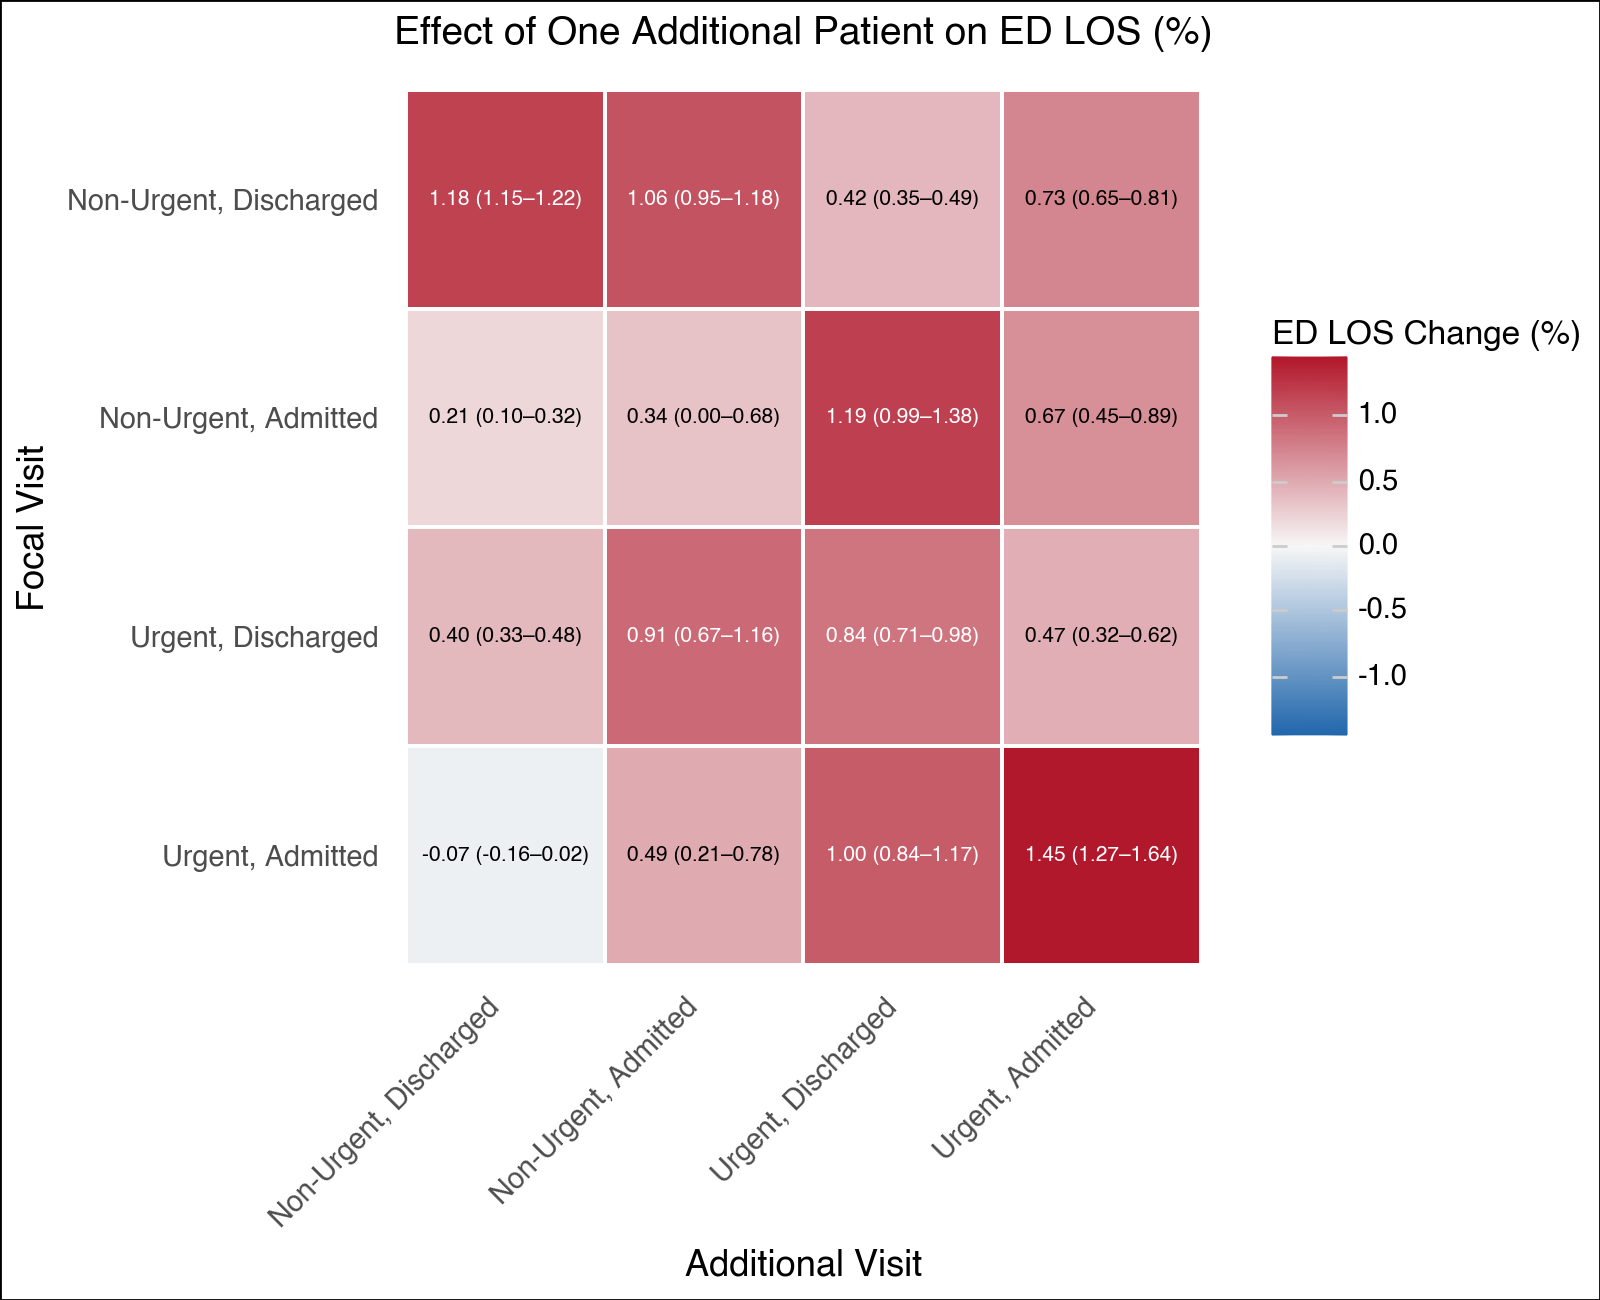

In [138]:

p_crowd = plot_annotated_heatmap(
    crowding_effects, index_col='visit_type', columns_col='crowding_type',
    value_col='ED LOS Change [Est.]', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, title='Effect of One Additional Patient on ED LOS (%)', ylab='Focal Visit', xlab='Additional Visit',
    save_path=save_filepath + '/outputs/fig_crowding_effects.pdf'
)
p_crowd

In [114]:
def pivot_to_latex(df, index_col, columns_col, annot_col, order,
                    caption, label, save_path=None):
    """
    Builds a LaTeX booktabs table from the long-form results, with a
    consistent category order and readable dashes for missing/diagonal cells.
    """
    wide = df.pivot(index=index_col, columns=columns_col, values=annot_col)
    wide = wide.reindex(index=order, columns=order)
    wide = wide.fillna('---')

    # ASCII-safe dash for LaTeX (avoids needing inputenc/xelatex for \u2013)
    wide = wide.apply(lambda col: col.astype(str).str.replace('\u2013', '--', regex=False))

    latex = wide.to_latex(
        escape=True,
        column_format='l' + 'c' * len(wide.columns),
        caption=caption,
        label=label,
        na_rep='---'
    )

    if save_path:
        with open(save_path, 'w') as f:
            f.write(latex)
    return latex


switching_latex = pivot_to_latex(
    switching_effects, index_col='from', columns_col='to', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, caption='Effect on ED LOS of switching focal visit type (\\% change, 95\\% CI).',
    label='tab:switching-effects',
    save_path=save_filepath + '/outputs/table_switching_effects.tex'
)
print(switching_latex)

crowding_latex = pivot_to_latex(
    crowding_effects, index_col='visit_type', columns_col='crowding_type', annot_col='ED LOS Change (%) [95% CI]',
    order=ORDER, caption='Effect of one additional patient in each crowding category on ED LOS (\\% change, 95\\% CI).',
    label='tab:crowding-effects',
    save_path=save_filepath + '/outputs/table_crowding_effects.tex'
)
print(crowding_latex)

\begin{table}
\caption{Effect on ED LOS of switching focal visit type (\% change, 95\% CI).}
\label{tab:switching-effects}
\begin{tabular}{lcccc}
\toprule
to & Non-Urgent, Discharged & Non-Urgent, Admitted & Urgent, Discharged & Urgent, Admitted \\
from &  &  &  &  \\
\midrule
Non-Urgent, Discharged & --- & 127.5 (121.9--133.2) & 56.0 (53.0--59.2) & 101.4 (96.9--106.0) \\
Non-Urgent, Admitted & -56.0 (-57.1---54.9) & --- & -31.4 (-33.4---29.3) & -11.5 (-14.2---8.6) \\
Urgent, Discharged & -35.9 (-37.2---34.6) & 45.8 (41.5--50.2) & --- & 29.1 (25.6--32.7) \\
Urgent, Admitted & -50.4 (-51.5---49.2) & 12.9 (9.4--16.6) & -22.5 (-24.6---20.4) & --- \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Effect of one additional patient in each crowding category on ED LOS (\% change, 95\% CI).}
\label{tab:crowding-effects}
\begin{tabular}{lcccc}
\toprule
crowding_type & Non-Urgent, Discharged & Non-Urgent, Admitted & Urgent, Discharged & Urgent, Admitted \\
visit_type &  &  &  &  \\

Plot heatmaps for this.

Now we're going to need to think about how to model LOS in an interactive way, as each prediction of LOS is going to affect everything else.

Things that do not change at any point:
--Disposition.
--Arrival times.
--The *baseline* crowding levels/ED LOS someone experienced in real life

Things that we get from the output prediction model:
--Urgency at arrival.

Things that we need to compute:
--How many people in each category are still there when someone arrives?

Probably the easiest way to do that is to keep a running count of crowding at each timepoint and update it at the arrival timestamps.


In [ ]:
#Load in switching/crowding effects and baseline model.
import joblib
from scipy.stats import norm
model = sm.load("ed-los-model.pkl")
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

#Identify the starting timestamp.
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load("split.joblib")
start_timestamp = visit_timeline.merge(csn_train, on='csn', how='inner')['arrival'].max()

#Define all types.
VISIT_TYPES = ['non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted']
REF_VISIT_TYPE = 'non-urgent-admitted'  # reference category: no dummy or interaction terms exist for this level

def _build_param_vector(visit_type, crowding_counts, crowding_types=VISIT_TYPES,
                          ref_visit_type=REF_VISIT_TYPE):
    """
    Translate a (visit_type, crowding_counts) state into the set of model
    coefficients "active" for that state, and their multipliers.
    """
    params = {}

    # Main crowding effect columns are only present if the model was fit
    # WITHOUT them (i.e. if crowding effects are captured entirely by the
    # interaction terms below). Given this formula, there is no separate
    # "Q('...')" main effect -- crowding enters ONLY through the
    # visit-type interaction. So we do NOT add a bare Q('k') term here.

    # Main effect dummy: only for non-reference visit types.
    if visit_type != ref_visit_type:
        params[f"C(visit_type)[T.{visit_type}]"] = 1

    # Interaction terms: present for EVERY visit type, including reference.
    for k, count in zip(crowding_types, crowding_counts):
        params[f"C(visit_type)[{visit_type}]:Q('{k}')"] = count

    return params

def generate_new_ed_los(
    model,
    old_ed_los,
    new_visit_type, new_crowding_counts,
    old_visit_type, old_crowding_counts,
    crowding_types=VISIT_TYPES,
    ref_visit_type=REF_VISIT_TYPE,
    rng=None
):
    """
    Simulate a patient's new ED length-of-stay (LOS) after both their visit
    type and the department's crowding levels change (e.g. as the result of
    a simulated uptriaging intervention).

    How the effect is computed
    ---------------------------
    The underlying model is linear on the log scale:

        log(LOS) = intercept + (visit-type effects) + (crowding main effects)
                   + (visit-type x crowding interaction effects) + ...

    The total effect of moving from an "old" state (old_visit_type,
    old_crowding_counts) to a "new" state (new_visit_type,
    new_crowding_counts) is the difference in the linear predictor between
    the two states -- a single linear contrast across the coefficients that
    differ between them. This function:

      1. Builds two parameter-multiplier dicts, one per state, via
         `_build_param_vector` (see above).
      2. Forms the net contrast (new minus old) across every parameter that
         appears in either state.
      3. Computes the point estimate of the log-scale change,
         `log_diff = contrast . beta`, and its exact variance,
         `var_diff = contrast' . Cov(beta) . contrast`, using the model's
         *full* coefficient covariance matrix -- this correctly accounts
         for correlation between e.g. a visit-type main effect and its own
         interaction terms, which a naive "add up marginal SEs" approach
         would miss.
      4. Draws ONE sample from Normal(log_diff, se_diff) as the simulated
         log-scale change for this patient, then applies it multiplicatively
         to `old_ed_los`.

    Because step 4 samples from a Normal centered at log_diff with SE
    se_diff, the sampled value falls within log_diff +/- 1.96*se_diff about
    95% of the time -- so this directly implements "draw a random effect
    from (something like) the 95% CI of the estimated change," but done
    correctly on the log scale, and using the joint (not marginal)
    uncertainty of the combined switching + crowding effect.

    Parameters
    ----------
    old_ed_los : float
        The patient's LOS (raw units, e.g. minutes) under the OLD state.
        This is treated as fixed/known -- only the multiplicative log-scale
        adjustment for the state change is random here.
    new_visit_type : str
        The visit type the patient is switched to.
    new_crowding_counts : np.ndarray
        Crowding counts under the NEW state, aligned with `crowding_types`.
    old_visit_type : str
        The patient's original visit type.
    old_crowding_counts : np.ndarray
        Crowding counts under the OLD state, aligned with `crowding_types`.
    model : statsmodels regression results object
        The fitted OLS model with `log_ed_los` as the outcome. Must expose
        `.params` and `.cov_params()`, and its parameter names must match
        the `C(visit_type)[T....]` / `Q('...')` naming convention assumed by
        `_build_param_vector`.
    crowding_types : list of str, optional
        Order of crowding buckets that `new_crowding_counts` and
        `old_crowding_counts` are aligned to. Defaults to the module-level
        `CROWDING_TYPES`.
    rng : numpy.random.Generator, optional
    Returns
    -------
    new_ed_los : float
        The simulated LOS under the new state (same units as `old_ed_los`).
    log_diff : float
        The point estimate of the log-scale change between old and new
        states (i.e. the mean of the distribution `new_ed_los` was sampled
        from, before exponentiating and applying to `old_ed_los`).
    se_diff : float
        The standard error of that log-scale change, computed from the
        model's full coefficient covariance matrix.

    """
    if rng is None:
        rng = np.random.default_rng()

    # Multiplier dicts for each state's set of "active" coefficients.
    params_old = _build_param_vector(old_visit_type, old_crowding_counts, crowding_types, ref_visit_type=ref_visit_type)
    params_new = _build_param_vector(new_visit_type, new_crowding_counts, crowding_types, ref_visit_type=ref_visit_type)

    # Net contrast: for every parameter appearing in either state, its
    # coefficient's effective multiplier is (new multiplier - old multiplier).
    # Parameters absent from a dict are implicitly 0 for that state.
    all_names = list(set(params_old) | set(params_new))
    contrast = pd.Series(
        {name: params_new.get(name, 0) - params_old.get(name, 0) for name in all_names}
    )

    # Align model coefficients and their covariance sub-block to the
    # contrast's parameter order. Any contrast parameter not in the model
    # (shouldn't happen if names are built correctly) would be filled with 0.
    beta = model.params.reindex(contrast.index).fillna(0)
    cov = model.cov_params().loc[contrast.index, contrast.index]

    # Point estimate and exact variance of the combined log-scale effect.
    log_diff = (contrast * beta).sum()
    var_diff = contrast.values @ cov.values @ contrast.values
    se_diff = np.sqrt(max(var_diff, 0))

    # One draw from the joint distribution of the combined effect.
    log_delta_sample = rng.normal(log_diff, se_diff)

    new_ed_los = old_ed_los * np.exp(log_delta_sample)

    return new_ed_los

#Generate this on an ongoing basis.
def simulate_ed_los_changes(
    model,
    arrival_times, #np.array
    departure_times, #np.array-- we will update this in a simulated fashion
    old_visit_types, #np.array of strings
    new_visit_types, #np.array of strings
    old_crowding_states, #list of np.arrays of size (crowding_types x arrival_timestamps), aligned with CROWDING_TYPES above
    old_ed_los_times,
    VISIT_TYPES=VISIT_TYPES,
    ref_visit_type=REF_VISIT_TYPE,
    simulation_start_time = 0,  #Everyone after this point gets affected by the updates.
    rng = None
):
    #Initialise the simulation: what is the current state of crowding?
    last_change_index = np.argmin(np.where(arrival_times <= simulation_start_time, simulation_start_time - arrival_times, np.Inf)) #Find the last arrival before the start time; if we are starting on an arrival, start here
    current_crowding_state = old_crowding_states[:, last_change_index].copy() # [non-urgent-discharged, ...]

    #Now iterate over the arrivals.
    arrival_index = np.argmin(np.where(arrival_times >= simulation_start_time, arrival_times - simulation_start_time, np.Inf)) #Find first arrival after the start time
    last_arrival_time = arrival_times[arrival_index] #In the very first deployment we can trust the real-world state and assume i.e. T_-1=T_0

    while arrival_index < len(arrival_times):

        #Load information about the focal visit.
        arrival, old_visit_type, new_visit_type, old_ed_los, old_crowding = (arrival_times[arrival_index], old_visit_types[arrival_index],
                                                                        new_visit_types[arrival_index], old_ed_los_times[arrival_index], old_crowding_states[:, arrival_index])
        
        
        #Find people who have left since the last arrival time and update the new state.
        finished_visits = np.where((departure_times <= arrival) & (departure_times > last_arrival_time))
        for v_index, visit_type in enumerate(VISIT_TYPES):
            current_crowding_state[v_index] -= np.sum(new_visit_types[finished_visits]==visit_type) #Number of people of this visit_type who have left
            if visit_type == new_visit_type:
                current_crowding_state[v_index] += 1 #Count the person who's just arrived!
        
        #Generate new ED LOS.
        new_ed_los = generate_new_ed_los(
            model,
            old_ed_los,
            new_visit_type, current_crowding_state,
            old_visit_type, old_crowding,
            crowding_types=VISIT_TYPES,
            ref_visit_type=ref_visit_type,
            rng=rng
        )

        #This becomes the focal visit's new departure time.
        departure_times[arrival_index] = arrival + new_ed_los

        #Update running indices.
        last_arrival_time = arrival
        arrival_index += 1
    
    #Now return a list of departure times.
    return departure_times

###-----SIMULATE DEPLOYMENT-------

#Attach the probabilities of deterioriation to non-urgent patients.
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)
visit_timeline = visit_timeline.merge(test_df[['csn', 'y_proba']], on='csn', how='left') #All urgent patients will have a probability of NA.




#Uptriage at a certain threshold.
def simulate_uptriage(visit_timeline, threshold):
    
    #Copy this to ensure no underlying changes.
    sim_vts = visit_timeline.copy()
    probs = sim_vts['y_proba'].values
    uptriages = ((~np.isnan(probs)) & (probs >= threshold))
    sim_vts['urgent'] = sim_vts['urgent'].where(uptriages, 1, sim_vts['urgent'])
    new_visit_types = np.where(uptriages,
            np.where(sim_vts['visit_type']=='non-urgent-admitted', 'urgent-admitted', 'urgent-discharged'), #Update visit-type for this non-urgent patients.
            sim_vts['visit_type'])

    return new_visit_types


#Take a seed and a threshold and simulate deployment.
def run_simulation(visit_timeline, threshold, seed=210226):

    #Simulate effect on visit times.
    rng = np.random.default_rng(seed=seed)
    arrival_times, departure_times = visit_timeline['arrival'].values, visit_timeline['arrival'].values + visit_timeline['ed_los'].values
    old_ed_los = visit_timeline['ed_los'].values
    old_crowding_states = np.array([visit_timeline[vtype].values for vtype in VISIT_TYPES])
    old_visit_types = visit_timeline['visit_type'].values

    #Extract new visit types.
    new_visit_types = simulate_uptriage(visit_timeline, threshold)

    new_departure_times = simulate_ed_los_changes(
        model,
        arrival_times, #np.array
        departure_times, #np.array-- we will update this in a simulated fashion
        old_visit_types, #np.array of strings
        new_visit_types, #np.array of strings
        old_crowding_states, #list of np.arrays of size (crowding_types x arrival_timestamps), aligned with CROWDING_TYPES above
        old_ed_los,
        VISIT_TYPES=VISIT_TYPES,
        ref_visit_type=REF_VISIT_TYPE,
        simulation_start_time = start_timestamp,  #Everyone after this point gets affected by the updates.
        rng = rng
    )

    return pd.DataFrame({
        'csn':visit_timeline['csn'],
        'new_departure_times':new_departure_times}).assign(
            Threshold=threshold, seed=seed
        )

#Now run this for, say, 10 seeds per threshold.
thresholds = np.linspace(0, 1, num=101)
seeds = list(range(1, 11))
params_to_test = list(product(thresholds, seeds))


#Run!
sim_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(run_simulation)(visit_timeline, threshold, seed=seed)
    for [threshold, seed] in params_to_test
)

sim_results = pd.concat(sim_results, ignore_index=True)
sim_results.to_csv("sim-results.csv")


    
    
    

,csn,urgent,is_admitted,ed_los,arrival,visit_type,non-urgent-discharged,urgent-admitted,urgent-discharged,non-urgent-admitted,y_proba
0,6124202846,0,0,113.0,0.0,non-urgent-discharged,1.0,0.0,0.0,0.0,NaN
1,6124202852,0,0,678.0,46.0,non-urgent-discharged,2.0,0.0,0.0,0.0,NaN
2,6124202854,0,0,132.0,51.0,non-urgent-discharged,3.0,0.0,0.0,0.0,NaN
3,6124202859,0,0,157.0,68.0,non-urgent-discharged,4.0,0.0,0.0,0.0,NaN
4,6124202864,0,0,218.0,84.0,non-urgent-discharged,5.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
305958,7014935446,0,0,418.0,2848257.0,non-urgent-discharged,13.0,1.0,3.0,4.0,0.008198
305959,7014935487,0,0,405.0,2848257.0,non-urgent-discharged,13.0,1.0,3.0,4.0,0.001261
305960,7014918264,0,0,445.0,2848275.0,non-urgent-discharged,14.0,1.0,3.0,4.0,0.006768
305961,7014935327,0,0,385.0,2848280.0,non-urgent-discharged,15.0,1.0,3.0,4.0,NaN


0.0
